<a href="https://colab.research.google.com/github/flynnight/Tubes-Siscer/blob/main/ML_Medical_Insurance_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perbandingan KNN dan DT Untuk Memprediksi Biaya Asuransi Kesehatan Menggunakan Variabel Smoker dan Age**

---
> **Level 2: AI-Assisted Idea Generation & Structuring**
---

## **1. Topik & Identitas**

Judul Studi Kasus: Perbandingan KNN dan Decision Tree Untuk Estimasi Biaya Asuransi Kesehatan Menggunakan Fitur Smoker dan Age

| Nama | NIM |
|------|-----|
| Fathahul Rizqa Arrahman | 103032430013 |
| Febriani Zahra | 103032400034 |
| Muhammad Maulana Darmawansyah | 103032400081 |



---
## 📦 Instalasi & Import Library

In [106]:
#untuk membaca dan mengolah dataset dalam bentuk tabel
import pandas as pd
#untuk operasi matematika dll
import numpy as np

#untuk membuat grafik (x, y)
import matplotlib.pyplot as plt
#untuk memperjelas grafik yang dibuat oleh matplotlib
import seaborn as sns

#mengubah data teks menjadi angka
from sklearn.preprocessing import LabelEncoder
#menyamakan skala data
from sklearn.preprocessing import StandardScaler

#untuk melakukan cross validation
from sklearn.model_selection import KFold
#mencari parameter yang terbaik secara otomatis
from sklearn.model_selection import GridSearchCV
#menghasilkan prediksi dengan cross validation
from sklearn.model_selection import cross_val_predict
#untuk R^2 Score
from sklearn.model_selection import cross_val_score

#model KNN untuk regresi
from sklearn.neighbors import KNeighborsRegressor
#model DT untuk regresi
from sklearn.tree import DecisionTreeRegressor

#berguna untuk mengukur kualitas dari model yang dipake
from sklearn.metrics import (
    #MAE (mean_absolute_error) berguna untuk menghitung rata-rata selisih absolut antara nilai sebenernya dengan nilai prediksi
    mean_absolute_error,
    #RMSE (root_mean_squared_error) berguna untuk menghitung akar kuadrat dari rata-rata selisih kuadrat antara nilai sebenernya dengan nilai prediksi
    mean_squared_error,
    #r2_score untuk mengukur seberapa besar variasi data yang dapat dijelaskan oleh model
    r2_score,
    #MAPE untuk mengukur kesalahan prediksi dalam persentase
    mean_absolute_percentage_error
)

#Digunakan untuk mengimpor fungsi sqrt() dari library bawaan Python math dan sqrt adalah singkatan dari Square Root (akar kuadrat)
from math import sqrt

print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Load Dataset

> **Cara upload dataset:**  
> 1. Download file `insurance.csv` dari [Kaggle](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)  
> 2. Upload ke Google Colab menggunakan cell di bawah

In [69]:
#untuk membaca file yang ada didalam kolom menggunakan fungsi pandas dan menyimpannya ke dalam variabel df
df = pd.read_csv('insurance.csv')

#untuk menampilkan jumlah baris dan kolom   yang ada di variabel df
print("Shape:", df.shape)
#untuk menampilkan 5 baris pertama yang ada didataset
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
## **2. Pendahuluan & Pemaparan Data**

### **2.1. Latar Belakang & Rumusan Masalah**

Biaya asuransi kesehatan dipengaruhi oleh berbagai faktor seperti usia, BMI, dan kebiasaan merokok. Oleh karena itu dilakukan perbandingan algoritma KNN dan Decision Tree untuk memprediksi biaya asuransi kesehatan.

**Rumusan Masalah:** Bagaimana perbandingan kinerja algoritma KNN dan Decision Tree dalam mengestimasi biaya asuransi kesehatan menggunakan faktor usia dan status perokok?

**Tujuan Penelitian:** Membandingkan kinerja algoritma K-Nearest Neighbor (KNN) dan Decision Tree dalam mengestimasi biaya asuransi kesehatan menggunakan faktor usia dan status perokok.

**Target Variabel:** `charges` (kontinu, USD) — ini adalah **masalah REGRESI**.


### **2.2. Deskripsi Dataset**

**Deskripsi Dataset**

"Machine Learning with R by Brett Lantz is a book that provides an introduction to machine learning using R. As far as I can tell, Packt Publishing does not make its datasets available online unless you buy the book and create a user account which can be a problem if you are checking the book out from the library or borrowing the book from a friend. All of these datasets are in the public domain but simply needed some cleaning up and recoding to match the format in the book."

**Sumber Dataset:** [Kaggle - Medical Cost Personal Datasets](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [71]:
# Encode data object
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [72]:
# Pecah fitur dan target
X = df[['age','smoker']]
y = df['charges']

In [73]:
# Statistik Deskriptif
#untuk menampilkan statistik deskriptif
df.describe().round(2)

,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338.00,1338.00,1338.00,1338.0,1338.00,1338.00
mean,39.21,0.51,30.66,1.09,0.2,1.52,13270.42
std,14.05,0.50,6.10,1.21,0.4,1.10,12110.01
min,18.00,0.00,15.96,0.00,0.0,0.00,1121.87
25%,27.00,0.00,26.30,0.00,0.0,1.00,4740.29
50%,39.00,1.00,30.40,1.00,0.0,2.00,9382.03
75%,51.00,1.00,34.69,2.00,0.0,2.00,16639.91
max,64.00,1.00,53.13,5.00,1.0,3.00,63770.43


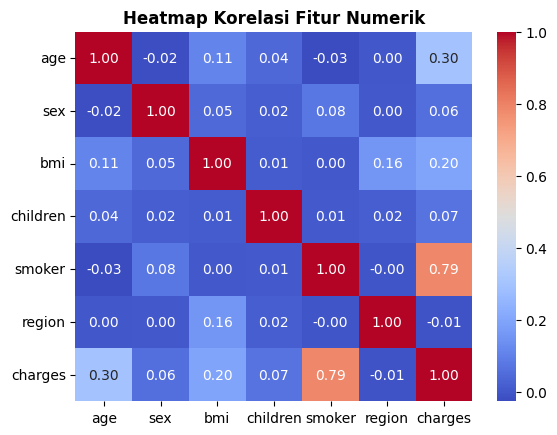

In [74]:
# Heatmap Korelasi
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,      #menampilkan angka
    fmt='.2f',       #format desimal
    cmap='coolwarm', #warna
)

plt.title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
plt.show()

Berdasarkan hasil analisis korelasi terhadap variabel target charges, smoker dan age memiliki nilai korelasi tertinggi sehingga dipilih sebagai fitur input model.

---
## 3. **Pra-Pemrosesan Data**
Pada tahap pra-pemrosesan data dilakukan seleksi fitur berdasarkan hasil analisis korelasi, yaitu usia (age) dan status perokok (smoker) sebagai variabel input serta biaya asuransi (charges) sebagai variabel target. Selanjutnya, variabel kategorikal smoker dikonversi menjadi data numerik menggunakan LabelEncoder. Data kemudian dipisahkan menjadi variabel input dan target, serta dilakukan normalisasi menggunakan StandardScaler untuk menyesuaikan skala data sebelum proses pelatihan model. Terakhir, digunakan metode K-Fold Cross Validation sebanyak 5 fold untuk memperoleh hasil evaluasi yang lebih reliabel.

### **3.1. Pembersihan Data (Cleaning)**
Dilakukan pemeriksaan missing values pada dataset menggunakan fungsi isnull().sum(). Hasil pemeriksaan menunjukkan bahwa tidak terdapat data yang hilang sehingga tidak diperlukan proses imputasi atau penghapusan data.

In [75]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### **3.2. Transformasi Data**
Variabel smoker yang berbentuk kategorikal (yes/no) diubah menjadi bentuk numerik menggunakan LabelEncoder agar dapat diproses oleh algoritma machine learning.

Data kemudian dinormalisasi menggunakan StandardScaler untuk menyamakan skala antar fitur sehingga tidak terjadi dominasi fitur tertentu pada proses pembelajaran model.

Rumus Normalisasi:

$$z = \frac{x - \mu}{\sigma}$$

Keterangan:


* x = nilai data
* μ = rata-rata data
* σ = standar deviasi

In [76]:
scaler = StandardScaler()

# mengambil data dan mentransform menggunakan rumus normalisasi
X_scaled = scaler.fit_transform(X)

# Ubah kembali menjadi DataFrame
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head().round(2)

,age,smoker
0,-1.44,1.97
1,-1.51,-0.51
2,-0.80,-0.51
3,-0.44,-0.51
4,-0.51,-0.51


### **3.3. Penanganan Missing Values**
Berdasarkan hasil pemeriksaan, dataset tidak memiliki missing values sehingga tidak diperlukan proses penanganan data hilang.

### **3.4. Feature Engineering**
Pada penelitian ini tidak dilakukan proses feature engineering karena fitur yang digunakan berasal langsung dari dataset dan telah dianggap representatif untuk proses pemodelan.

---
## **4. Penanganan Imbalanced Data**

Penelitian ini menggunakan pendekatan regresi untuk mengestimasi biaya asuransi kesehatan (charges) yang berupa data numerik kontinu. Oleh karena itu, permasalahan ketidakseimbangan kelas (imbalanced data) yang umumnya ditemukan pada tugas klasifikasi tidak menjadi fokus pada penelitian ini. Dengan demikian, teknik penanganan data tidak seimbang seperti SMOTE, undersampling, oversampling, maupun class weighting tidak diterapkan.

Meskipun distribusi target charges cenderung tidak simetris (right-skewed), penelitian ini tetap menggunakan data asli tanpa teknik penyeimbangan data karena target yang diprediksi merupakan variabel kontinu.

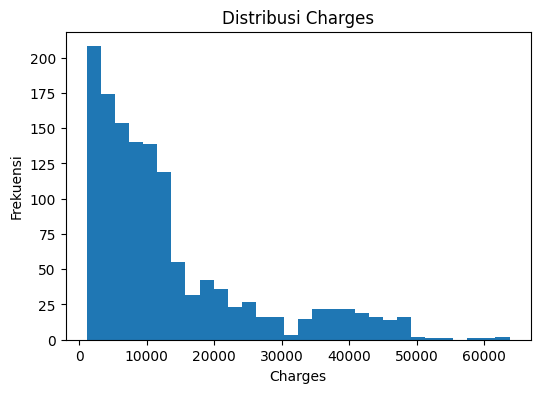

In [78]:
plt.figure(figsize=(6,4))          # ukuran grafik (lebar = 6 inci, tinggi = 4 inci)
plt.hist(df['charges'], bins=30)   # membuat histogram
plt.title('Distribusi Charges')
plt.xlabel('Charges')
plt.ylabel('Frekuensi')
plt.show()

---
## **5. Metode dan Eksperimen**

### **5.1. Konsep Algoritma**

**1. K-Nearest Neighbors Regressor**  
K-Nearest Neighbor (KNN) merupakan algoritma machine learning yang melakukan prediksi berdasarkan sejumlah tetangga terdekat dari suatu data. Pada penelitian ini, KNN digunakan untuk mengestimasi biaya asuransi kesehatan berdasarkan usia dan status perokok.

Jarak antar data biasanya dihitung menggunakan Euclidean Distance:

$$d = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

Keterangan:
* $d$ = Jarak Euclidean antara dua titik/objek
* $n$ = Jumlah dimensi atau total fitur data
* $i$ = Indeks dimensi/fitur saat ini (mulai dari 1 sampai $n$)
* $x_i$ = Nilai koordinat titik pertama pada dimensi ke-$i$
* $y_i$ = Nilai koordinat titik kedua pada dimensi ke-$i$

Semakin dekat jarak antar data, semakin besar pengaruh data tersebut terhadap hasil prediksi.

**2. Decision Tree**

Decision Tree Regressor membangun struktur pohon keputusan dengan memilih pemisahan data yang menghasilkan nilai Mean Squared Error (MSE) terkecil pada setiap node. Proses ini dilakukan secara berulang hingga diperoleh struktur pohon yang mampu memprediksi nilai target dengan tingkat kesalahan yang minimum.

Rumus MSE:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2$$

Keterangan:


* $y_i$ = nilai target aktual
* $\bar{y}$ = rata-rata nilai target
* $n$ = jumlah data



Pada penelitian ini, Decision Tree digunakan untuk mengestimasi biaya asuransi kesehatan berdasarkan usia dan status perokok.

Keunggulan Decision Tree:


* Mudah dipahami
* Tidak memerlukan asumsi distribusi data
* Mampu menangani hubungan non-linear



### **5.2 Cross Validation**
Penelitian ini menggunakan metode K-Fold Cross Validation dengan 5 fold untuk mengevaluasi performa model. Pada metode ini, dataset dibagi menjadi lima bagian. Secara bergantian satu bagian digunakan sebagai data pengujian dan empat bagian lainnya digunakan sebagai data pelatihan. Metode ini dipilih karena mampu menghasilkan evaluasi yang lebih stabil dibandingkan pembagian data sederhana menggunakan train-test split.

In [81]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(kf)

KFold(n_splits=5, random_state=42, shuffle=True)


In [98]:
# KNN
knn = KNeighborsRegressor(n_neighbors=5)

cv_knn = cross_val_score(
    knn,
    X_scaled,
    y,
    cv=5,
    scoring='r2'
)

print("R² tiap fold KNN:")
print(cv_knn)

print("\nRata-rata R² KNN:")
print(cv_knn.mean())

R² tiap fold KNN:
[0.71867639 0.63844408 0.67704205 0.6406869  0.68628304]

Rata-rata R² KNN:
0.6722264954741608


In [97]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)

cv_dt = cross_val_score(
    dt,
    X_scaled,
    y,
    cv=5,
    scoring='r2'
)

print("R² tiap fold Decision Tree:")
print(cv_dt)

print("\nRata-rata R² Decision Tree:")
print(cv_dt.mean())

R² tiap fold Decision Tree:
[0.68017459 0.64162025 0.69296843 0.64532064 0.66812385]

Rata-rata R² Decision Tree:
0.665641552005961


### **5.3 Hyperparameter Tuning dengan GridSearchCV**
GridSearchCV digunakan untuk mencari kombinasi parameter terbaik secara otomatis dengan mencoba seluruh kombinasi parameter yang telah ditentukan dan mengevaluasinya menggunakan Cross Validation.

In [82]:
# KNN
param_knn = {
    'n_neighbors': range(1, 21)
}

grid_knn = GridSearchCV(
    knn,
    param_knn,
    cv=5,
    scoring='r2'
)

grid_knn.fit(X_scaled, y)

print(grid_knn.best_params_)

{'n_neighbors': 19}


Hasil tersebut menunjukkan bahwa model KNN dengan 19 tetangga terdekat menghasilkan nilai R² tertinggi dibandingkan nilai n_neighbors lainnya yang diuji. Oleh karena itu, nilai n_neighbors = 19 digunakan pada model KNN akhir untuk proses evaluasi dan perbandingan dengan algoritma Decision Tree.

In [83]:
# Decision Tree
param_dt = {
    'max_depth': [3,5,7,9],
    'min_samples_split': [2,5,10]
}

grid_dt = GridSearchCV(
    dt,
    param_dt,
    cv=5,
    scoring='r2'
)

grid_dt.fit(X_scaled, y)

print(grid_dt.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


Hyperparameter tuning dilakukan menggunakan GridSearchCV dengan kombinasi parameter max_depth sebesar 3, 5, 7, dan 9 serta min_samples_split sebesar 2, 5, dan 10. Berdasarkan hasil pencarian, kombinasi parameter terbaik yang diperoleh adalah max_depth = 3 dan min_samples_split = 2. Kombinasi tersebut menghasilkan nilai R² tertinggi pada proses 5-Fold Cross Validation sehingga digunakan pada model Decision Tree akhir.

---
## **6. Hasil & Analisis***

## **6.1. Tabel Perbandingan Metrik**
Evaluasi kinerja model dilakukan menggunakan tiga metrik regresi, yaitu Mean Absolute Error (MAE), Mean Squared Error (MSE), dan Coefficient of Determination (R² Score). Ketiga metrik tersebut digunakan untuk mengukur tingkat kesalahan prediksi serta kemampuan model dalam menjelaskan variasi data target.

**Mean Absolute Error (MAE)**

MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi.

Rumus:
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Keterangan:


* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

Semakin kecil nilai MAE, semakin baik performa model.

**Mean Squared Error (MSE)**

MSE mengukur rata-rata kuadrat kesalahan antara nilai aktual dan nilai prediksi.

Rumus:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Keterangan:


* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

Semakin kecil nilai MSE, semakin baik performa model. Metrik ini memberikan penalti yang lebih besar terhadap kesalahan prediksi yang besar.

**R² Score**

R² Score mengukur kemampuan model dalam menjelaskan variasi data target.

Rumus:
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Keterangan:

* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi
* $\bar{y}$ = rata-rata nilai aktual

Nilai R² berada pada rentang (−∞,1]. Semakin mendekati 1, semakin baik kemampuan model dalam menjelaskan variasi data.

**Mean Absolute Percentage Error (MAPE)**

MAPE mengukur rata-rata persentase kesalahan prediksi terhadap nilai aktual.

Rumus:
$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Keterangan:

* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

In [99]:
# gunakan model terbaik hasil tuning
knn_best = grid_knn.best_estimator_
dt_best = grid_dt.best_estimator_

In [100]:
# Membuat prediksi KNN menggunakan 5-Fold Cross Validation
knn_pred = cross_val_predict(
    knn_best,
    X_scaled,
    y,
    cv=5
)

# Membuat prediksi Decision Tree menggunakan 5-Fold Cross Validation
dt_pred = cross_val_predict(
    dt_best,
    X_scaled,
    y,
    cv=5
)

In [107]:
# Implementasi Evaluasi
mae_knn = mean_absolute_error(y, knn_pred)
mse_knn = mean_squared_error(y, knn_pred)
rmse_knn = sqrt(mse_knn)
r2_knn = r2_score(y, knn_pred)
mape_knn = mean_absolute_percentage_error(y, knn_pred) * 100

mae_dt = mean_absolute_error(y, dt_pred)
mse_dt = mean_squared_error(y, dt_pred)
rmse_dt = sqrt(mse_dt)
r2_dt = r2_score(y, dt_pred)
mape_dt = mean_absolute_percentage_error(y, dt_pred) * 100

In [109]:
# Tabel Perbandingan Metrik
results = pd.DataFrame({
    'Model':['KNN','Decision Tree'],
    'MAE':[mae_knn, mae_dt],
    'MSE':[mse_knn, mse_dt],
    'RMSE':[rmse_knn, rmse_dt],
    'MAPE':[mape_knn, mape_dt],
    'R²':[r2_knn, r2_dt]
})



results.style.format({
    'MAE': '{:,.4f}',
    'MSE': '{:,.4f}',
    'RMSE': '{:,.4f}',
    'MAPE': '{:.2f}%',
    'R²': '{:.4f}'
})

,Model,MAE,MSE,RMSE,MAPE,R²
0,KNN,"4,187.8896","42,804,747.7261",6542.533739,37.53%,0.7079
1,Decision Tree,"4,232.2306","42,568,330.1190",6524.440981,41.01%,0.7095


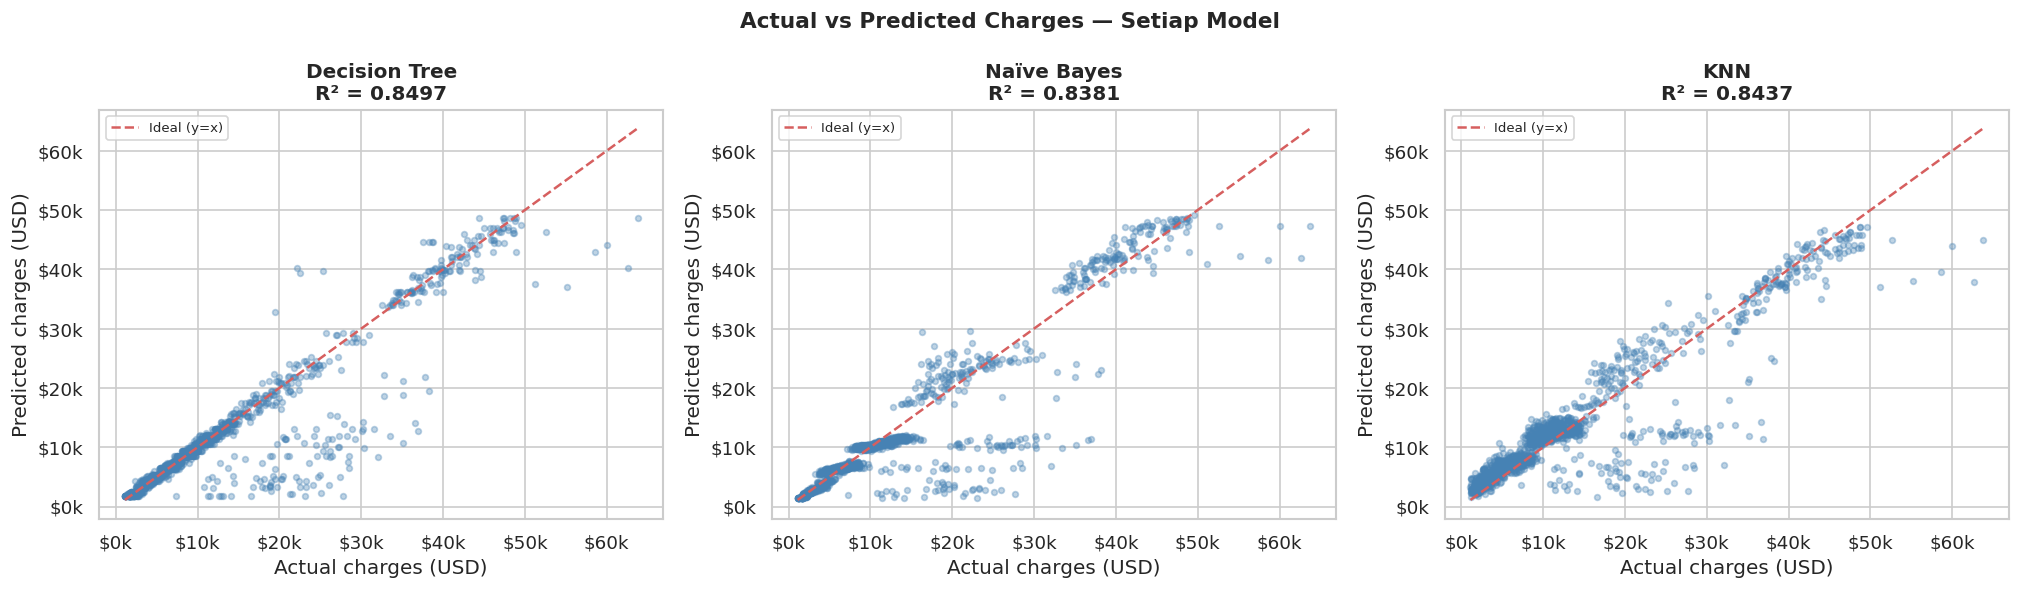

In [ ]:
# ============================================================
# 3.6.2 — Scatter Plot: Actual vs Predicted
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Actual vs Predicted Charges — Setiap Model', fontsize=13, fontweight='bold')

for ax, name, pred in zip(axes, model_names, preds_all):
    r2 = r2_score(y, pred)
    ax.scatter(y, pred, alpha=0.35, s=12, color='steelblue')
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y=x)')
    ax.set_xlabel('Actual charges (USD)')
    ax.set_ylabel('Predicted charges (USD)')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

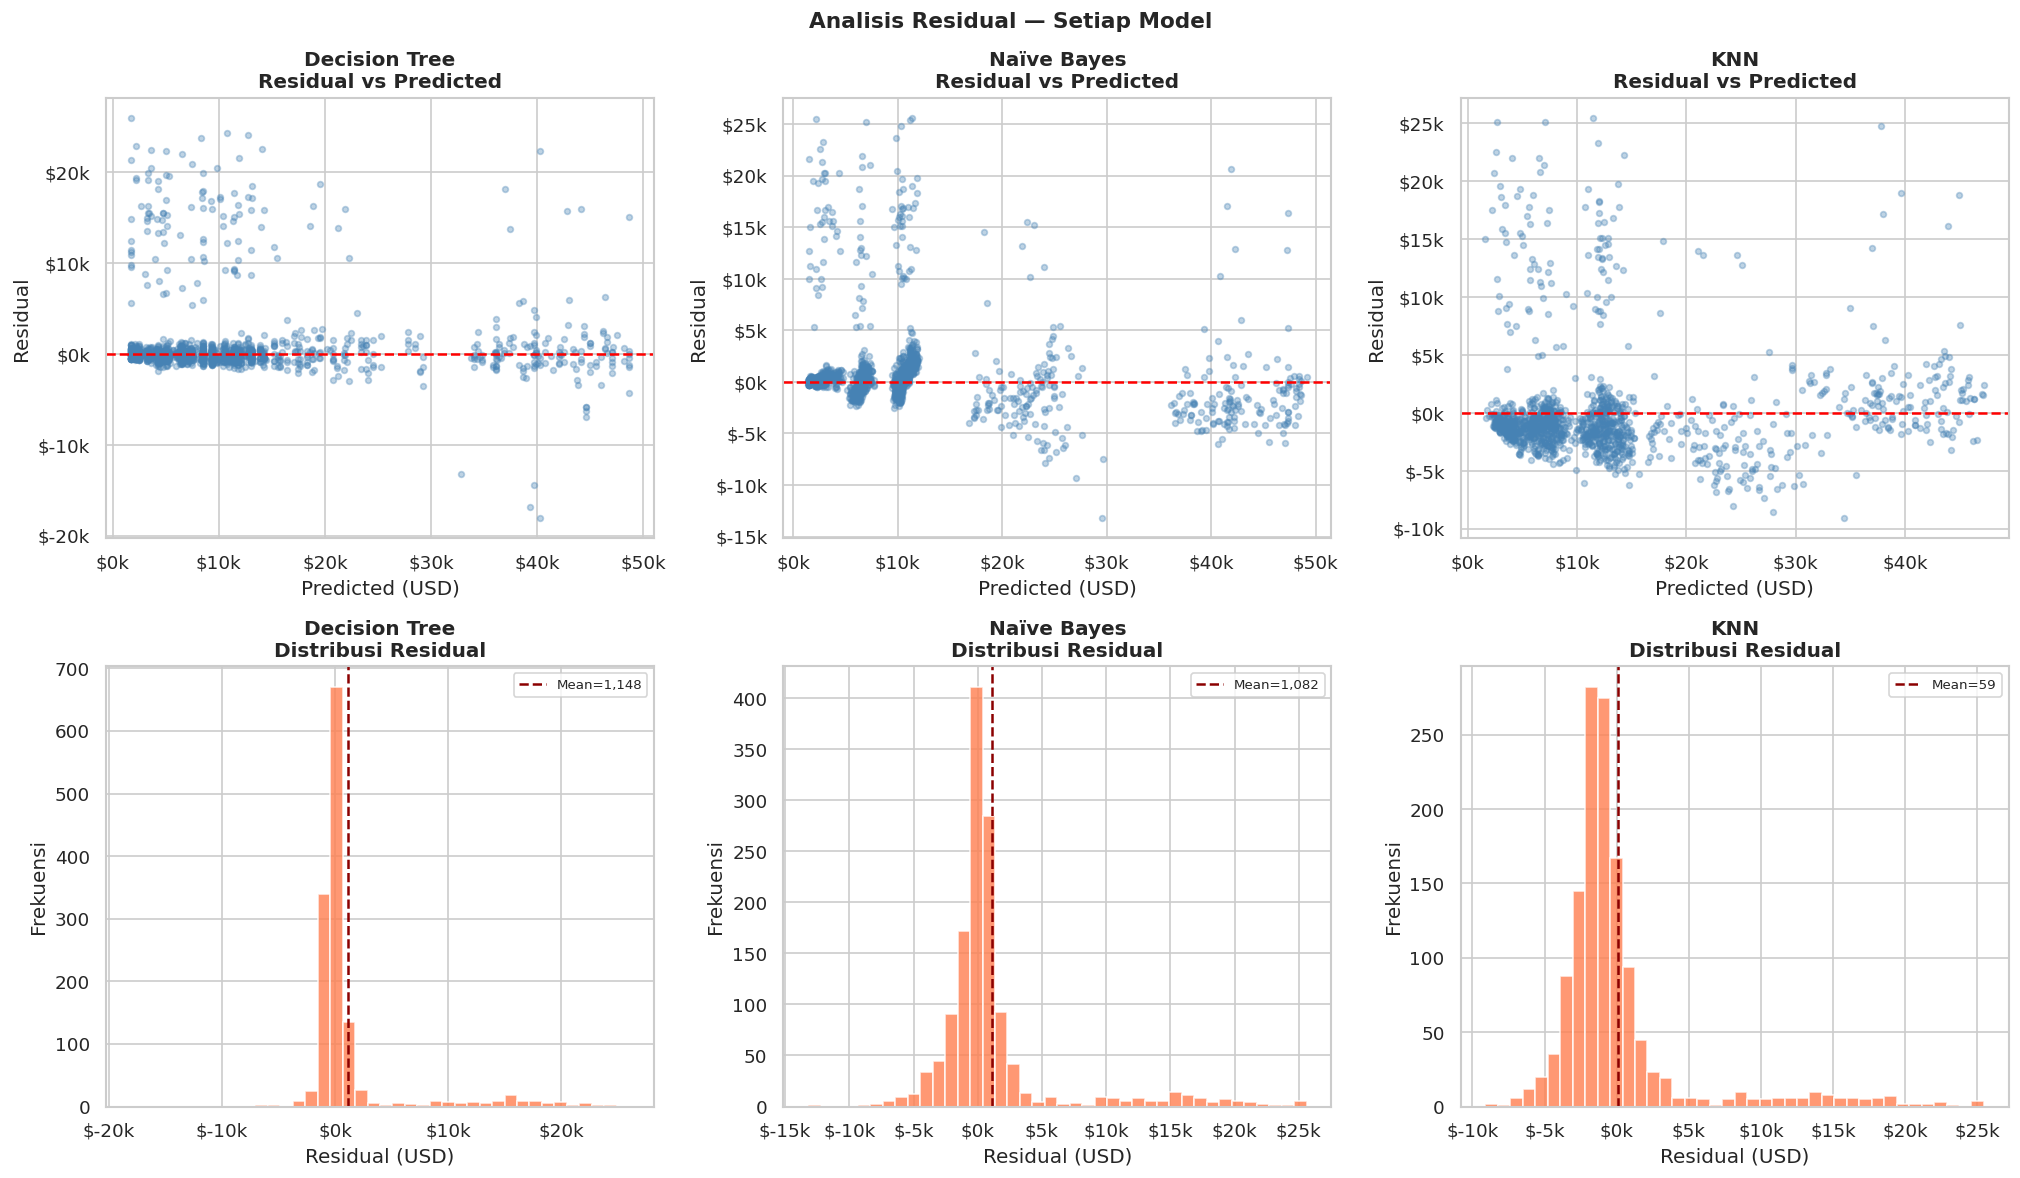

In [ ]:
# ============================================================
# 3.6.3 — Residual Analysis (Error Analysis)
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Analisis Residual — Setiap Model', fontsize=13, fontweight='bold')

for i, (name, pred) in enumerate(zip(model_names, preds_all)):
    residuals = np.array(y) - np.array(pred)

    # Residual vs Predicted
    axes[0, i].scatter(pred, residuals, alpha=0.35, s=12, color='steelblue')
    axes[0, i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0, i].set_title(f'{name}\nResidual vs Predicted', fontweight='bold')
    axes[0, i].set_xlabel('Predicted (USD)')
    axes[0, i].set_ylabel('Residual')
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[0, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

    # Distribusi Residual
    axes[1, i].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
    axes[1, i].axvline(residuals.mean(), color='darkred', linestyle='--',
                        linewidth=1.5, label=f'Mean={residuals.mean():,.0f}')
    axes[1, i].set_title(f'{name}\nDistribusi Residual', fontweight='bold')
    axes[1, i].set_xlabel('Residual (USD)')
    axes[1, i].set_ylabel('Frekuensi')
    axes[1, i].legend(fontsize=8)
    axes[1, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

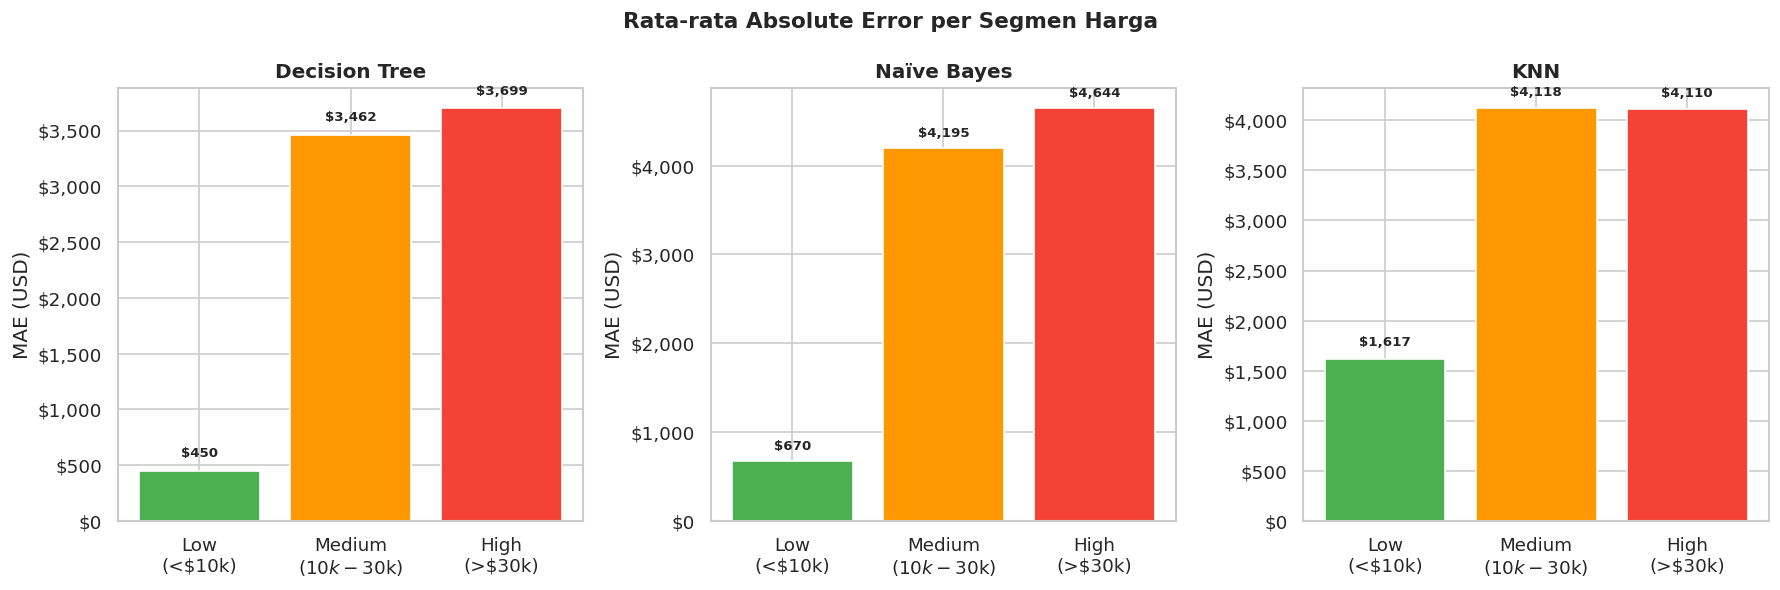


MAE per Segmen Harga:


,Decision Tree,Naïve Bayes,KNN
Low (<$10k),$450.38,$669.88,"$1,617.12"
Medium ($10k-$30k),"$3,461.90","$4,195.13","$4,118.38"
High (>$30k),"$3,698.53","$4,644.29","$4,110.49"


In [ ]:
# ============================================================
# 3.6.4 — Error Segmentation: Error per Range Charges
# (Analog dengan analisis confidence pada klasifikasi)
# ============================================================
bins_labels = ['Low\n(<$10k)', 'Medium\n($10k-$30k)', 'High\n(>$30k)'
]
bins = [0, 10000, 30000, 100000]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Rata-rata Absolute Error per Segmen Harga', fontsize=13, fontweight='bold')

for ax, name, pred in zip(axes, model_names, preds_all):
    y_np      = np.array(y)
    pred_np   = np.array(pred)
    abs_error = np.abs(y_np - pred_np)

    seg_mae = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_np >= lo) & (y_np < hi)
        seg_mae.append(abs_error[mask].mean() if mask.sum() > 0 else 0)

    colors = ['#4CAF50', '#FF9800', '#F44336']
    bars = ax.bar(bins_labels, seg_mae, color=colors, edgecolor='white')
    for bar, val in zip(bars, seg_mae):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'${val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('MAE (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Tabel Numerik
print('\nMAE per Segmen Harga:')
seg_data = {}
for name, pred in zip(model_names, preds_all):
    y_np    = np.array(y)
    abs_err = np.abs(y_np - np.array(pred))
    row = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_np >= lo) & (y_np < hi)
        row.append(abs_err[mask].mean() if mask.sum() > 0 else 0)
    seg_data[name] = row

seg_df = pd.DataFrame(seg_data, index=['Low (<$10k)', 'Medium ($10k-$30k)', 'High (>$30k)']).round(2)
seg_df.applymap(lambda x: f'${x:,.2f}')

In [ ]:
# ============================================================
# 3.6.5 — Worst Predictions: Observasi dengan Error Terbesar
# ============================================================
print('=== Analisis Kesalahan Terbesar (Top-10 per Model) ===\n')

for name, pred in zip(model_names, preds_all):
    abs_err    = np.abs(np.array(y) - np.array(pred))
    pct_err    = abs_err / (np.array(y) + 1e-8) * 100
    top10_idx  = np.argsort(abs_err)[-10:][::-1]

    print(f'[{name}] — Top-10 prediksi terburuk (error absolut terbesar):')
    detail = df.iloc[top10_idx][['age', 'bmi', 'smoker', 'charges']].copy()
    detail['predicted']   = pred[top10_idx].round(2)
    detail['abs_error']   = abs_err[top10_idx].round(2)
    detail['pct_error']   = pct_err[top10_idx].round(2)
    detail.columns = ['age', 'bmi', 'smoker', 'actual', 'predicted', 'abs_error', 'pct_error%']
    print(detail.to_string(index=False))
    print(f'  Rata-rata error terbesar: ${abs_err[top10_idx].mean():,.2f}\n')

=== Analisis Kesalahan Terbesar (Top-10 per Model) ===

[Decision Tree] — Top-10 prediksi terburuk (error absolut terbesar):
 age    bmi smoker      actual  predicted  abs_error  pct_error%
  20 35.310     no 27724.28875    1719.90   26004.39       93.80
  55 26.800     no 35160.13457   10796.35   24363.78       69.29
  59 34.800     no 36910.60803   12784.63   24125.98       65.36
  44 29.735     no 32108.66282    8360.44   23748.22       73.96
  24 23.210     no 25081.76784    2211.13   22870.64       91.18
  61 33.330     no 36580.28216   14063.42   22516.86       61.55
  21 32.680     no 26018.95052    3591.48   22427.47       86.20
  45 30.360    yes 62592.87309   40224.08   22368.79       35.74
  34 22.420     no 27375.90478    5068.84   22307.06       81.48
  40 41.420     no 28476.73499    6498.56   21978.17       77.18
  Rata-rata error terbesar: $23,271.14

[Naïve Bayes] — Top-10 prediksi terburuk (error absolut terbesar):
 age    bmi smoker      actual  predicted  abs_error 

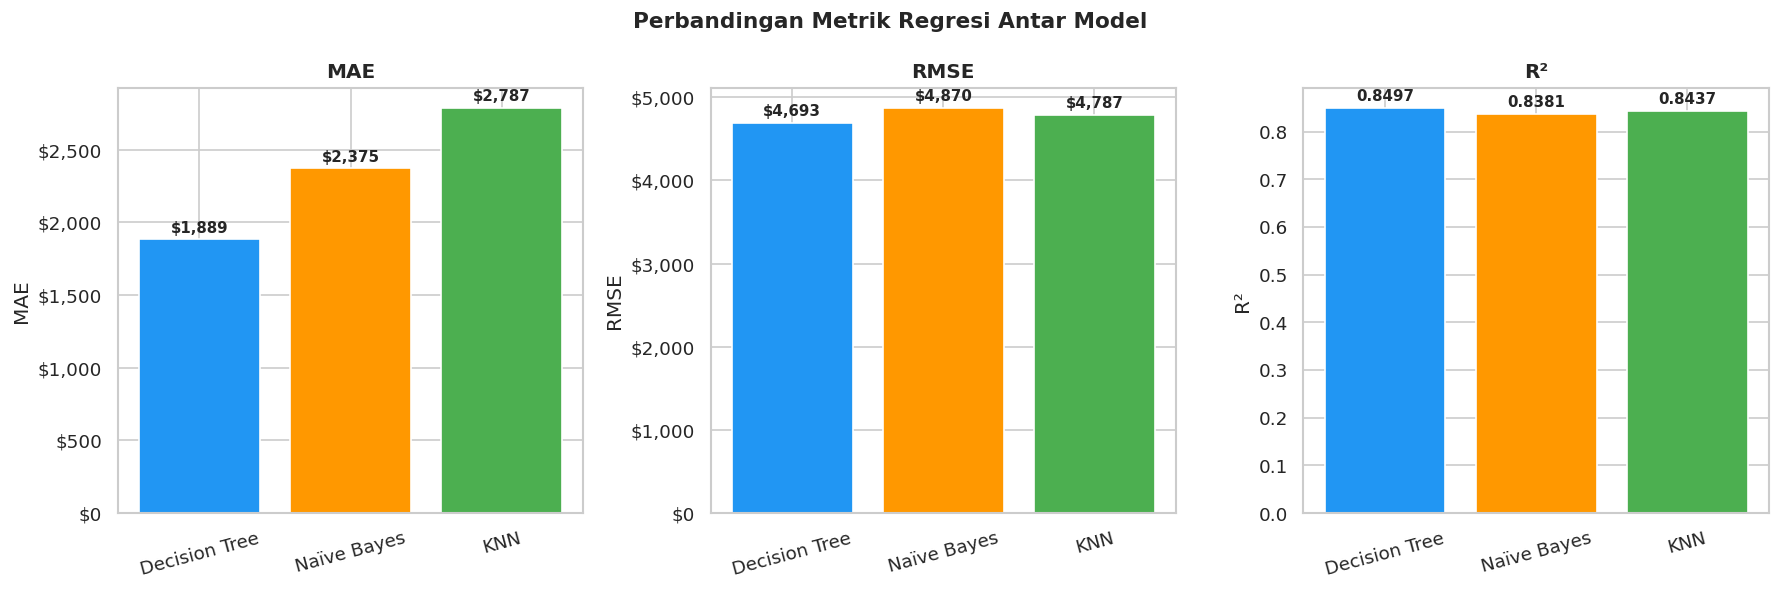

In [ ]:
# ============================================================
# 3.6.6 — Bar Chart Ringkasan Metrik Numerik
# ============================================================
metrics_num = {
    name: regression_metrics(y, pred)
    for name, pred in zip(model_names, preds_all)
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perbandingan Metrik Regresi Antar Model', fontsize=13, fontweight='bold')

colors = ['#2196F3', '#FF9800', '#4CAF50']

for metric, ax in zip(['MAE', 'RMSE', 'R²'], axes):
    vals = [metrics_num[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        label = f'{val:.4f}' if metric == 'R²' else f'${val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    if metric in ['MAE', 'RMSE']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

---
## 3.7 Kesimpulan

In [ ]:
# ============================================================
# RINGKASAN AKHIR
# ============================================================
metrics_num_df = pd.DataFrame(metrics_num).T.round(2)
metrics_num_df['MAE']  = metrics_num_df['MAE'].apply(lambda x: f'${x:,.2f}')
metrics_num_df['RMSE'] = metrics_num_df['RMSE'].apply(lambda x: f'${x:,.2f}')
metrics_num_df['MAPE'] = metrics_num_df['MAPE'].apply(lambda x: f'{x:.2f}%')

print('=' * 65)
print('  RINGKASAN HASIL EKSPERIMEN — REGRESI')
print('=' * 65)
print(metrics_num_df.to_string())

# Pemenang
r2_vals  = {n: metrics_num[n]['R²'] for n in model_names}
mae_vals = {n: metrics_num[n]['MAE'] for n in model_names}
best_r2  = max(r2_vals, key=r2_vals.get)
best_mae = min(mae_vals, key=mae_vals.get)

print(f'\n🏆 Model dengan R² tertinggi  : {best_r2} ({r2_vals[best_r2]:.4f})')
print(f'🏆 Model dengan MAE terendah  : {best_mae} (${mae_vals[best_mae]:,.2f})')

print('\nCatatan Interpretasi:')
print('  - Decision Tree : tangkap non-linearitas, cenderung overfit tanpa pruning')
print('  - Naïve Bayes   : ringan & cepat, akurasi regresi terbatas (asumsi kuat)')
print('  - KNN           : performa solid, tapi lambat saat prediksi data besar')
print('  - Fitur smoker + interaksi smoker_bmi / smoker_age sangat dominan')
print('  - Segmen "High" charges cenderung lebih sulit diprediksi semua model')

  RINGKASAN HASIL EKSPERIMEN — REGRESI
                     MAE       RMSE    R²    MAPE
Decision Tree  $1,889.08  $4,692.94  0.85  13.19%
Naïve Bayes    $2,374.87  $4,870.46  0.84  16.49%
KNN            $2,787.29  $4,786.61  0.84  31.93%

🏆 Model dengan R² tertinggi  : Decision Tree (0.8497)
🏆 Model dengan MAE terendah  : Decision Tree ($1,889.08)

Catatan Interpretasi:
  - Decision Tree : tangkap non-linearitas, cenderung overfit tanpa pruning
  - Naïve Bayes   : ringan & cepat, akurasi regresi terbatas (asumsi kuat)
  - KNN           : performa solid, tapi lambat saat prediksi data besar
  - Fitur smoker + interaksi smoker_bmi / smoker_age sangat dominan
  - Segmen "High" charges cenderung lebih sulit diprediksi semua model
